# 基于 LOPIT 空间蛋白质组学的蛋白亚细胞定位预测

**课程：计算机生物学与人工智能｜中国药科大学·药学硕士课程作业**  
**研究类型：公开真实数据的教学性再分析**

本项目研究：不同亚细胞区室的蛋白是否具有可区分的分馏谱？机器学习能否根据分馏谱预测参考蛋白的定位，并为未标注蛋白提供候选定位？

分析路线：数据质控 → 参考标签统计 → 分层划分 → 训练集交叉验证 → 独立测试 → PCA与混淆矩阵 → 未标注蛋白候选预测。

这是一份可学习、修改并复现的课程项目。提交时请按课程要求补充作者信息，并确认自己理解代码和结果。

## 1. 科学背景与药学意义

蛋白的功能不仅取决于丰度，也取决于其所处的亚细胞环境。LOPIT 将亚细胞分馏与定量质谱结合，用蛋白在不同分馏中的相对分布刻画空间信息。这里的“空间”指亚细胞定位，不是组织切片上的二维坐标。

本项目使用 Tan 等（2009）的果蝇数据，来自 pRolocdata 的第一重复 CSV。该数据规模小、可随仓库保存，适合完整复现。它不是人类疾病或药物干预数据；本分析可作为理解靶点定位、细胞器功能和后续药物扰动研究的技术练习，不能直接推导临床疗效或药物机制。

原始论文：[Mapping organelle proteins and protein complexes in Drosophila melanogaster](https://doi.org/10.1021/pr800866n)。数据整理来源：[pRolocdata](https://github.com/lgatto/pRolocdata)。

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import platform
import importlib.metadata
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
assert (ROOT / 'src' / 'analysis.py').exists(), '请在项目根目录运行 Notebook'
sys.path.insert(0, str(ROOT))
from src.analysis import load_data, run_analysis, SEED, FEATURES

print('Python:', platform.python_version())
print('Random seed:', SEED)
for package in ['numpy', 'pandas', 'scikit-learn', 'matplotlib']:
    print(package, importlib.metadata.version(package))

Python: 3.12.14
Random seed: 42
numpy 2.5.3
pandas 3.0.6
scikit-learn 1.9.1
matplotlib 3.11.2


## 2. 数据来源、完整性与标签含义

每行是一个蛋白，输入特征仅为 `area 114` 至 `area 117` 四个 iTRAQ 通道。标签使用 CSV 的 `pd.markers` 参考标记列。`PLS-DA classification` 和 `pd.2013` 为已有分析注释，不作为输入或训练目标，以免把已有算法输出当作真值。

上游脚本说明：`pd.markers` 包括原有标记，以及通过 phenoDisco 发现并经 UniProtKB/文献核查的补充标记。因此标签选择曾利用该数据的结构，随机留出测试不能消除这种历史筛选偏差，结果应理解为“对当前参考注释的一致性评估”。这些注释不等于新的独立实验验证；相关上游脚本和文档保存在 `data/`。`unknown` 表示缺少参考标签，不是一个可训练的细胞器类别。

In [2]:
provenance = json.loads((ROOT / 'data/provenance.json').read_text(encoding='utf-8'))
actual_hash = hashlib.sha256((ROOT / 'data/tan2009_rep1.csv').read_bytes()).hexdigest()
assert actual_hash == provenance['sha256'], '数据校验失败'
print('Upstream commit:', provenance['upstream_commit'])
print('SHA-256 verified:', actual_hash)
raw, X = load_data(ROOT)
display(raw[['FBgn', 'Flybase Symbol', *FEATURES, 'label']].head())
display(pd.DataFrame({
    '指标': ['蛋白数', '输入特征数', '重复ID', '缺失强度', '参考标记蛋白', '未标记蛋白'],
    '数值': [len(raw), X.shape[1], raw.FBgn.duplicated().sum(),
             raw[FEATURES].isna().sum().sum(),
             (raw.label != 'unknown').sum(), (raw.label == 'unknown').sum()]
}))

Upstream commit: f717d11e22beab97deca6b82306b00367cf55fca
SHA-256 verified: 96ab42c26517b0ef38e60234c766351572d8b460777aecc16f2e6a6836934250


,FBgn,Flybase Symbol,area 114,area 115,area 116,area 117,label
0,FBgn0001104,G-ialpha65A,0.379000,0.281000,0.225000,0.114000,unknown
1,FBgn0000044,Act57B,0.420000,0.209667,0.206111,0.163889,unknown
2,FBgn0035720,CG10077,0.187333,0.167333,0.169667,0.476000,unknown
3,FBgn0003731,Egfr,0.247500,0.253000,0.320000,0.179000,unknown
4,FBgn0029506,Tsp42Ee,0.216000,0.183000,0.342000,0.259000,unknown


,指标,数值
0,蛋白数,888
1,输入特征数,4
2,重复ID,0
3,缺失强度,0
4,参考标记蛋白,144
5,未标记蛋白,744


## 3. 方法与评价设计

1. 检查 ID 唯一性、缺失值、非负强度和非零行总和；按蛋白做行归一化，表示各分馏的相对比例。这是每个样本独立的变换，不利用其他样本。
2. 仅对至少有 6 个参考标记的类别做分层 70%/30% 训练—测试划分；4 个 Peroxisome 标记保留在原始数据中，但排除出本次监督学习，不混入 unknown。
3. 固定随机种子 42。训练集上做三折分层交叉验证，比较多数类基线、RBF-SVM 与随机森林。SVM 的标准化放入 Pipeline，在各训练折内拟合。
4. 以训练交叉验证的宏平均 F1 在两种真实分类器中选模型，测试集仅用于最终评估一次。超参数预先固定，无测试集调参。
5. 同时报 Accuracy、Balanced accuracy 和 Macro-F1。Macro-F1 对每个类别等权，比单独准确率更能揭示少数类表现。
6. 评估完成后用全部合格参考标记重新拟合模型，输出 unknown 蛋白的候选定位。模型是封闭类别分类器，不具备新细胞器发现、双重定位识别或可靠拒识能力。

参与建模的参考标记                  140
类别数                         10
训练集                         98
测试集                         42
未标记蛋白                      744
排除的小样本类别     {'Peroxisome': 4}
Name: 数据划分, dtype: object

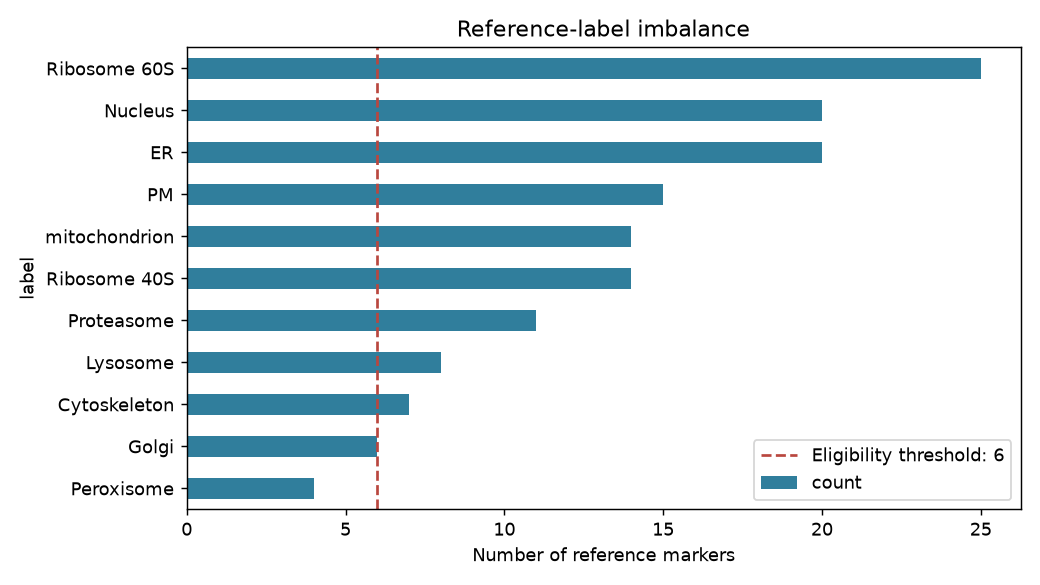

In [3]:
summary, cv_results, report, candidates = run_analysis(ROOT)
display(pd.Series({
    '参与建模的参考标记': summary['eligible_markers'],
    '类别数': len(summary['classes']),
    '训练集': summary['train_n'],
    '测试集': summary['test_n'],
    '未标记蛋白': summary['unknown_n'],
    '排除的小样本类别': summary['excluded_rare_classes'],
}, name='数据划分'))
display(Image(filename=str(ROOT / 'results/marker_counts.png')))

## 4. 空间分布可视化

PCA 的标准化和主成分方向只在训练标记上拟合，然后投影其他蛋白。图中颜色表示数据提供的参考标签，灰色表示未标记蛋白。类别交叠提示分馏谱相似或分辨率不足；二维图上的接近不能证明蛋白相互作用。第二张图为全部参考标记的描述性平均分馏谱，不参与模型选择。

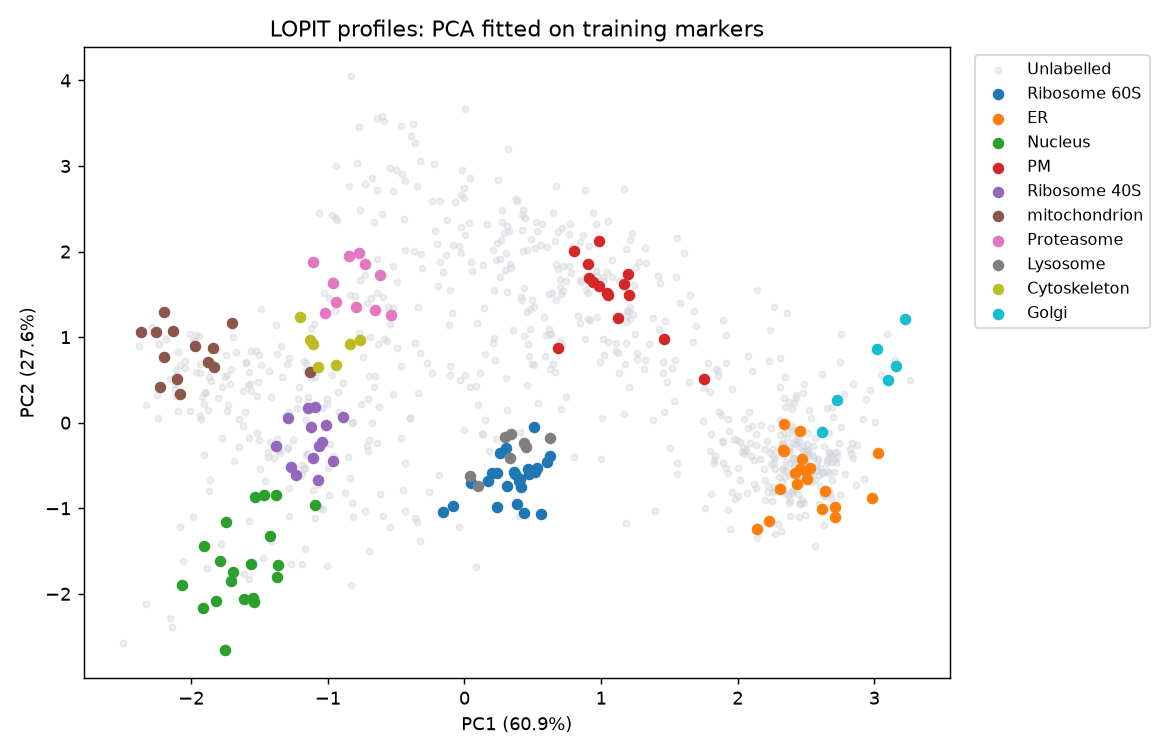

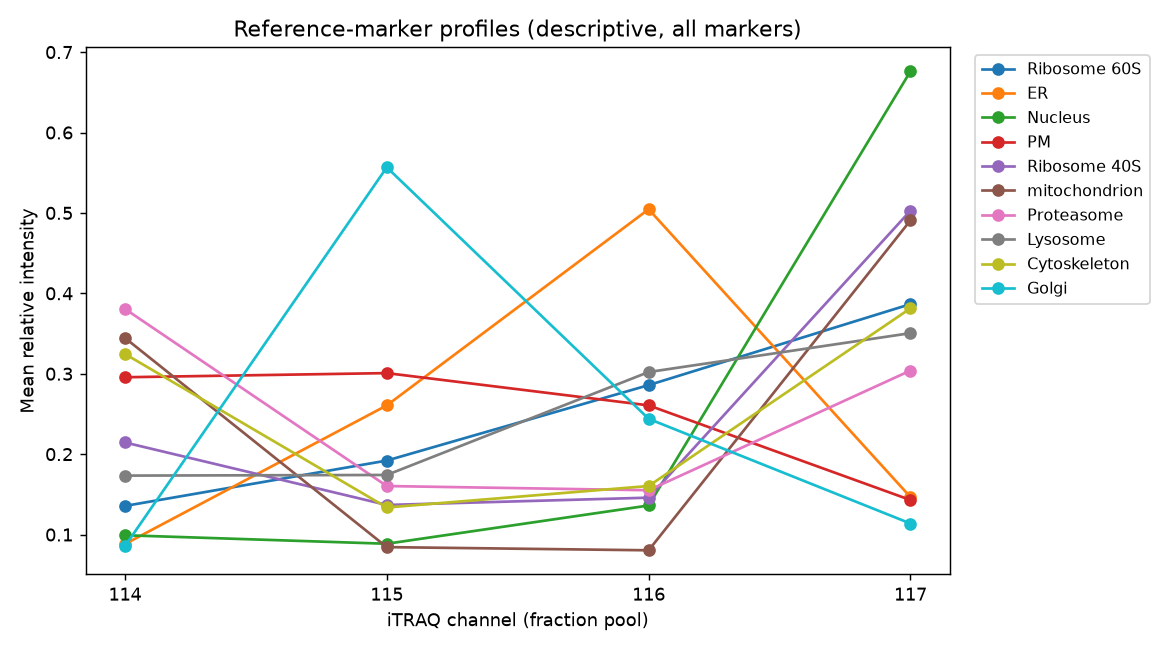

前两个主成分累计解释方差： 88.4%


In [4]:
display(Image(filename=str(ROOT / 'results/pca.png')))
display(Image(filename=str(ROOT / 'results/profiles.png')))
print('前两个主成分累计解释方差：',
      f"{sum(summary['pca_variance_ratio']):.1%}")

## 5. 训练集模型比较与独立测试

交叉验证标准差只描述这三折之间的波动，不是置信区间。测试集每类蛋白数量较少，个别错误会明显改变对应类别的 F1，因此避免仅凭单次划分宣布模型具有普遍优势。

,cv_macro_f1_mean,cv_macro_f1_sd,cv_accuracy_mean
model,,,
Dummy,0.0296,0.0028,0.1736
SVM,0.8522,0.0070,0.8980
RandomForest,0.9134,0.0395,0.9492


按训练交叉验证选出的模型： RandomForest


accuracy             0.9762
balanced_accuracy    0.9500
macro_f1             0.9608
Name: Held-out test, dtype: float64

,precision,recall,f1-score,support
Ribosome 60S,0.889,1.000,0.941,8.000
ER,1.000,1.000,1.000,6.000
Nucleus,1.000,1.000,1.000,6.000
PM,1.000,1.000,1.000,5.000
Ribosome 40S,1.000,1.000,1.000,4.000
mitochondrion,1.000,1.000,1.000,4.000
Proteasome,1.000,1.000,1.000,3.000
Lysosome,1.000,0.500,0.667,2.000
Cytoskeleton,1.000,1.000,1.000,2.000
Golgi,1.000,1.000,1.000,2.000


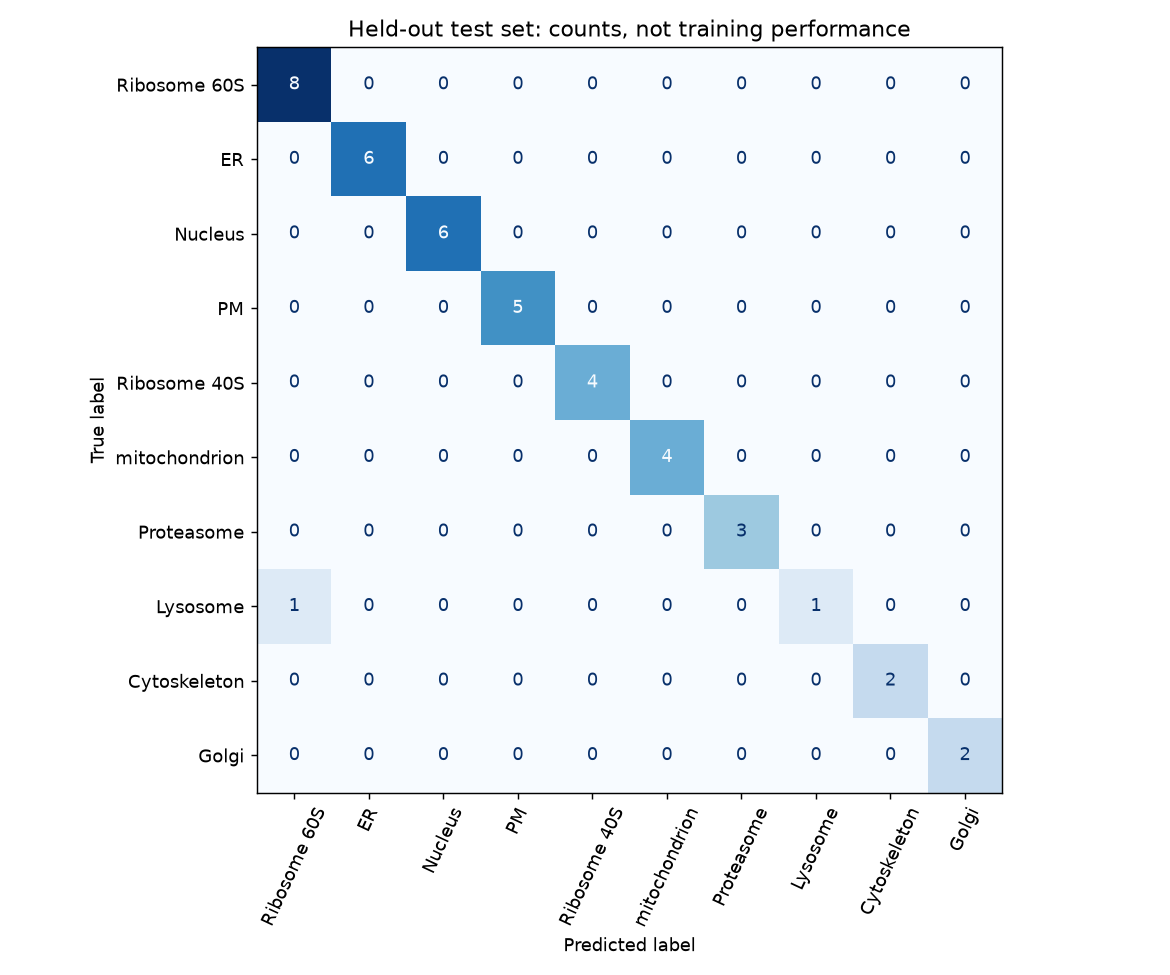

In [5]:
display(cv_results.round(4))
print('按训练交叉验证选出的模型：', summary['selected_model'])
display(pd.Series(summary['test_metrics'], name='Held-out test').round(4))
display(report.round(3))
display(Image(filename=str(ROOT / 'results/confusion_matrix.png')))

In [6]:
from sklearn.metrics import f1_score
split = pd.read_csv(ROOT / 'results/split.csv')
test_predictions = pd.read_csv(ROOT / 'results/test_predictions.csv')
train_ids = set(split.loc[split.split == 'train', 'FBgn'])
test_ids = set(split.loc[split.split == 'test', 'FBgn'])
assert not train_ids.intersection(test_ids)
assert set(test_predictions.FBgn) == test_ids
recomputed_f1 = f1_score(test_predictions.label, test_predictions.prediction, average='macro')
assert np.isclose(recomputed_f1, summary['test_metrics']['macro_f1'])
assert len(candidates) == (raw.label == 'unknown').sum()
assert set(candidates.predicted_compartment).issubset(summary['classes'])
print('通过：训练/测试互斥、指标可重算、预测数量和类别合法。')

通过：训练/测试互斥、指标可重算、预测数量和类别合法。


## 6. 未标记蛋白的候选定位

下表按原数据顺序展示前十个预测，不是“最可信前十名”。完整结果保存于 `results/unlabelled_predictions.csv`。未标记蛋白可能属于训练中未覆盖的区室，因此这些输出仅是后续验证候选，不能把 744 个预测都宣称为新发现。

本项目不输出未经校准的“可信概率”，也不声称已完成药物靶点验证。若未来研究感兴趣的蛋白，可结合实验体系选择免疫荧光、亚细胞分馏后免疫印迹或其他定位验证方法。

In [7]:
display(candidates.head(10))
display(candidates.predicted_compartment.value_counts().rename('候选数量').to_frame())

,FBgn,Flybase Symbol,predicted_compartment,interpretation
0,FBgn0001104,G-ialpha65A,PM,candidate_only_not_experimentally_validated
1,FBgn0000044,Act57B,PM,candidate_only_not_experimentally_validated
2,FBgn0035720,CG10077,Ribosome 40S,candidate_only_not_experimentally_validated
3,FBgn0003731,Egfr,PM,candidate_only_not_experimentally_validated
4,FBgn0029506,Tsp42Ee,Lysosome,candidate_only_not_experimentally_validated
7,FBgn0031871,CG10158,ER,candidate_only_not_experimentally_validated
8,FBgn0040227,eIF-3p66,Ribosome 40S,candidate_only_not_experimentally_validated
10,FBgn0037443,CG1021,ER,candidate_only_not_experimentally_validated
11,FBgn0028475,CG10221,ER,candidate_only_not_experimentally_validated
14,FBgn0002526,LanA,PM,candidate_only_not_experimentally_validated


,候选数量
predicted_compartment,
ER,211
PM,197
mitochondrion,73
Proteasome,68
Ribosome 40S,66
Golgi,42
Lysosome,28
Nucleus,28
Cytoskeleton,21


## 7. 结果解释与局限

以下文字直接使用本次运行结果生成，避免手写指标与代码不一致。

In [8]:
m = summary['test_metrics']
class_report = report.reindex(summary['classes'])
weakest = class_report['f1-score'].idxmin()
display(Markdown(
    f"本次纳入 **{summary['proteins']}** 个蛋白，其中 **{summary['eligible_markers']}** 个参考标记"
    f"用于 **{len(summary['classes'])}** 类监督学习。训练集为 **{summary['train_n']}** 个蛋白，"
    f"独立测试集为 **{summary['test_n']}** 个蛋白。训练交叉验证选择 **{summary['selected_model']}**；"
    f"测试准确率 **{m['accuracy']:.3f}**，平衡准确率 **{m['balanced_accuracy']:.3f}**，"
    f"宏平均 F1 **{m['macro_f1']:.3f}**。本次测试中 F1 最低的类别之一为 **{weakest}**。"
    f"共为 **{summary['unknown_n']}** 个未标记蛋白生成候选定位。"
))

本次纳入 **888** 个蛋白，其中 **140** 个参考标记用于 **10** 类监督学习。训练集为 **98** 个蛋白，独立测试集为 **42** 个蛋白。训练交叉验证选择 **RandomForest**；测试准确率 **0.976**，平衡准确率 **0.950**，宏平均 F1 **0.961**。本次测试中 F1 最低的类别之一为 **Lysosome**。共为 **744** 个未标记蛋白生成候选定位。

**局限与下一步：**

- 只有第一重复的四个分馏通道，不等同于多批次、大规模 hyperLOPIT 研究；不评估跨实验泛化。
- 标记集规模小且不均衡；蛋白复合体成员之间并不独立，按蛋白随机划分可能对实际跨批次预测偏乐观。
- `pd.markers` 为已有参考注释，可能存在标注偏差；这不是盲法实验验证。
- Peroxisome 因样本不足被排除；多定位蛋白、训练外类别和动态转位不在当前模型能力内。
- 本数据为果蝇，不可直接外推到人类药学场景。将方法迁移至课题组数据时，需要核实物种、分馏方案、批次和标记集。
- 后续可采用更多实验重复、按复合体/批次分组验证，以及校准与拒识方法；不能仅通过提高训练准确率证明改进。

**结论：** 本项目展示了从真实空间蛋白质组学数据到机器学习评估及候选定位输出的完整流程。其价值在于流程可检查、可复现，预测结论仍需独立数据和实验验证。

## 8. 参考资料与复现

1. Tan DJ et al. Mapping organelle proteins and protein complexes in Drosophila melanogaster. *J Proteome Res.* 2009;8(6):2667–2678. DOI: [10.1021/pr800866n](https://doi.org/10.1021/pr800866n).
2. [pRolocdata 原始仓库](https://github.com/lgatto/pRolocdata)，本项目固定数据版本并提供 SHA-256，见 `data/provenance.json`。
3. [scikit-learn Pipeline](https://scikit-learn.org/stable/modules/compose.html#pipeline)、[交叉验证](https://scikit-learn.org/stable/modules/cross_validation.html)。

环境安装、Git 提交、版本标签和提交链接说明见 `README.md`。Notebook 是结果展示入口，计算逻辑位于 `src/analysis.py`。